# NETWORK MODELING FOR INFECTIOUS DISEASE SPREAD

- Temporal Modeling - Temporal Convolutional Neural Network (TCN)

In [ ]:
%pip install keras-tcn

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

from tcn import TCN

import random
import torch

def set_seed(seed=11):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(11)


# Data Preparation

In [ ]:
# Loading merged dataset
df = pd.read_csv("df_high_burden.csv")
# Data Overview
df.head()

,state,county,year,MMWR WEEK,Label,previous_52_week_max,latitude,longitude,population_estimate,income,Label_grouped,Disease_Group
0,ALABAMA,Chilton,2022,1,"Arboviral diseases, West Nile virus disease",2,32.756889,-86.844516,45868.0,43434.0,Arboviral diseases,Vector-borne
1,ALABAMA,Chilton,2022,1,Campylobacteriosis,39,32.756889,-86.844516,45868.0,43434.0,Campylobacteriosis,Enteric
2,ALABAMA,Chilton,2022,1,Coccidioidomycosis,2,32.756889,-86.844516,45868.0,43434.0,Coccidioidomycosis,Fungal
3,ALABAMA,Chilton,2022,1,Cryptosporidiosis,7,32.756889,-86.844516,45868.0,43434.0,Cryptosporidiosis,Enteric
4,ALABAMA,Chilton,2022,1,Cyclosporiasis,3,32.756889,-86.844516,45868.0,43434.0,Cyclosporiasis,Enteric


In [ ]:
# Data Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174042 entries, 0 to 174041
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   state                 174042 non-null  object 
 1   county                174042 non-null  object 
 2   year                  174042 non-null  int64  
 3   MMWR WEEK             174042 non-null  int64  
 4   Label                 174042 non-null  object 
 5   previous_52_week_max  174042 non-null  int64  
 6   latitude              174042 non-null  float64
 7   longitude             174042 non-null  float64
 8   population_estimate   174042 non-null  float64
 9   income                174042 non-null  float64
 10  Label_grouped         174042 non-null  object 
 11  Disease_Group         174042 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 15.9+ MB


In [ ]:
# Sorting Data by State, County, Label, Year, and MMWR Week
df = df.sort_values(
    ["state", "county", "Label", "year", "MMWR WEEK"]
).reset_index(drop=True)

## Encoding Categorical Variabes

In [ ]:
# Encodings for state, county, and infection labels
state_enc = LabelEncoder()
county_enc = LabelEncoder()
infection_enc = LabelEncoder()

# Encoding Process
df["state_id"] = state_enc.fit_transform(df["state"])
df["county_id"] = county_enc.fit_transform(df["county"])
df["infection_id"] = infection_enc.fit_transform(df["Label"])

## Feature Engineering - Cyclical Encoding to Fix MMwR WEEK

Week 1 and Week 52 are next to each other and should be considered adjacent in the context of the spread of infections. Current int type places Week 1 and Week 2 far from each other.

In [ ]:
# Cyclical encoding for MMWR WEEK

df["week_sin"] = np.sin(
    2 * np.pi * df["MMWR WEEK"] / 52
)

df["week_cos"] = np.cos(
    2 * np.pi * df["MMWR WEEK"] / 52
)

# Temporal Convolutional Neural Network (TCN)

## Data Preprocessing

In [ ]:
# Target variable and features
TARGET = "previous_52_week_max"

# Log Transformation for Target
df[TARGET]= np.log1p(df[TARGET].values).astype(np.float32)

# Lags
df["lag_1"] = df.groupby(["state", "county"])[TARGET].shift(1)
df["lag_2"] = df.groupby(["state", "county"])[TARGET].shift(2)
df["lag_3"] = df.groupby(["state", "county"])[TARGET].shift(3)
df["lag_4"] = df.groupby(["state", "county"])[TARGET].shift(4)

# Dropping NaNs
df = df.dropna()


feature_cols = [
    "state_id",
    "county_id",
    "infection_id",
    "year",
    "week_sin",
    "week_cos",
    "latitude",
    "longitude",
    "population_estimate",
    "income",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4"
]

### Scaling Features

In [ ]:
# Data Preprocessing: Scaling features
scaler = StandardScaler()

df[feature_cols] = scaler.fit_transform(
    df[feature_cols]
)

### Temporal Sequences

In [ ]:
# Creating windows aligned with 52 weeks
SEQ_LEN = 52

X = []
y = []

group_cols = ["state", "county", "Label"]

for _, grp in df.groupby(group_cols):

    grp = grp.sort_values(
        ["year", "MMWR WEEK"]
    )

    features = grp[feature_cols].values
    target = grp[TARGET].values

    if len(grp) <= SEQ_LEN:
        continue

    for i in range(len(grp) - SEQ_LEN):

        X.append(
            features[i:i + SEQ_LEN]
        )

        y.append(
            target[i + SEQ_LEN]
        )

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (64895, 52, 14)
y shape: (64895,)


### Data Partitioning

In [ ]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## TCN Model

# Spatial Feature Engineering

In [ ]:
from scipy.spatial.distance import cdist
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# Create coordinate matrix for all unique counties
unique_counties = df.drop_duplicates(subset=["county", "latitude", "longitude"])[["county", "latitude", "longitude"]]
coords = unique_counties[["latitude", "longitude"]].values
county_names = unique_counties["county"].values

# Compute distance matrix (in km, approximate using Haversine would be more accurate)
dist_matrix = cdist(coords, coords, metric='euclidean')

# Find k-nearest neighbors (k=5)
k_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors+1, algorithm='ball_tree').fit(coords)
distances, indices = nbrs.kneighbors(coords)

# Create spatial weight matrix (inverse distance)
spatial_weights = np.zeros_like(dist_matrix)
for i in range(len(coords)):
    for j in range(1, k_neighbors+1):  # Skip self (index 0)
        neighbor_idx = indices[i, j]
        # Inverse distance weighting
        spatial_weights[i, neighbor_idx] = 1 / (distances[i, j] + 1e-6)

# Normalize rows
spatial_weights = spatial_weights / (spatial_weights.sum(axis=1, keepdims=True) + 1e-9)

print(f"Spatial weights matrix shape: {spatial_weights.shape}")
print(f"Number of unique counties: {len(county_names)}")
print(f"K-nearest neighbors: {k_neighbors}")

Spatial weights matrix shape: (190, 190)
Number of unique counties: 190
K-nearest neighbors: 5


In [ ]:
# Compute spatial lag features for each county-infection group
def compute_spatial_lag_features(df, spatial_weights, county_names, feature_cols_spatial):
    """
    Compute spatial lag features representing neighbor influences
    """
    df_enhanced = df.copy()

    # Create mapping from county name to spatial weight index
    county_to_idx = {name: idx for idx, name in enumerate(county_names)}

    for feat in feature_cols_spatial:
        lag_col_name = f"{feat}_spatial_lag"
        df_enhanced[lag_col_name] = 0.0

        for county in df["county"].unique():
            if county not in county_to_idx:
                continue

            county_idx = county_to_idx[county]
            county_mask = df_enhanced["county"] == county

            # Get all data for this county
            county_data = df_enhanced[county_mask].copy()

            # Compute weighted average from neighbors
            neighbor_indices = np.where(spatial_weights[county_idx] > 0)[0]
            neighbor_counties = [county_names[i] for i in neighbor_indices if i != county_idx]

            if len(neighbor_counties) > 0:
                neighbor_data = df_enhanced[df_enhanced["county"].isin(neighbor_counties)]
                if len(neighbor_data) > 0:
                    spatial_lag = neighbor_data.groupby("county")[feat].transform(
                        lambda x: x.mean() * spatial_weights[county_idx, county_to_idx[x.name]]
                    ).sum() / len(neighbor_counties)

                    # Assign to all rows of this county
                    df_enhanced.loc[county_mask, lag_col_name] = (
                        df_enhanced.loc[county_mask, feat].values + 0.3 * spatial_lag
                    )

    return df_enhanced

# Compute spatial lag features for key variables
feature_cols_spatial = ["population_estimate", "income"]
df_with_spatial = compute_spatial_lag_features(df, spatial_weights, county_names, feature_cols_spatial)

print("Spatial lag features computed:")
for feat in feature_cols_spatial:
    print(f"  - {feat}_spatial_lag")
print(f"\nDataframe shape: {df_with_spatial.shape}")

Spatial lag features computed:
  - population_estimate_spatial_lag
  - income_spatial_lag

Dataframe shape: (173694, 23)


# Gaussian Bayesian Network (GBN) Component

In [ ]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.regularizers import l2

class GaussianBayesianNetworkLayer(layers.Layer):
    """
    Custom Keras layer implementing a Gaussian Bayesian Network
    Models probabilistic dependencies between input variables
    """

    def __init__(self, hidden_dim=32, **kwargs):
        super(GaussianBayesianNetworkLayer, self).__init__(**kwargs)
        self.hidden_dim = hidden_dim

    def build(self, input_shape):
        # Mean parameters for Gaussian distributions
        self.mean_weights = self.add_weight(
            name='mean_weights',
            shape=(input_shape[-1], self.hidden_dim),
            initializer='glorot_uniform',
            trainable=True,
            regularizer=l2(1e-5)
        )
        self.mean_bias = self.add_weight(
            name='mean_bias',
            shape=(self.hidden_dim,),
            initializer='zeros',
            trainable=True
        )

        # Variance parameters (log-space for positivity)
        self.log_var_weights = self.add_weight(
            name='log_var_weights',
            shape=(input_shape[-1], self.hidden_dim),
            initializer='glorot_uniform',
            trainable=True,
            regularizer=l2(1e-5)
        )
        self.log_var_bias = self.add_weight(
            name='log_var_bias',
            shape=(self.hidden_dim,),
            initializer=tf.constant_initializer(-1.0),
            trainable=True
        )

        # Covariance structure weights for dependencies
        self.covar_weights = self.add_weight(
            name='covar_weights',
            shape=(input_shape[-1], self.hidden_dim, self.hidden_dim),
            initializer='orthogonal',
            trainable=True,
            regularizer=l2(1e-5)
        )

        super(GaussianBayesianNetworkLayer, self).build(input_shape)

    def call(self, inputs):
        # Compute means
        means = tf.matmul(inputs, self.mean_weights) + self.mean_bias

        # Compute log-variances and convert to positive values
        log_vars = tf.matmul(inputs, self.log_var_weights) + self.log_var_bias
        variances = tf.exp(log_vars)

        # Compute probabilistic features combining mean and variance
        # This captures the Gaussian distribution characteristics
        std = tf.sqrt(variances + 1e-8)

        # Sample from Gaussian distribution (reparameterization trick)
        epsilon = tf.random.normal(shape=tf.shape(means))
        samples = means + epsilon * std

        # Combine samples with variance information
        outputs = tf.concat([samples, std], axis=-1)

        return outputs

    def get_config(self):
        config = super().get_config()
        config.update({"hidden_dim": self.hidden_dim})
        return config

print("Gaussian Bayesian Network Layer defined")

Gaussian Bayesian Network Layer defined


In [ ]:
class SpatialEncoderLayer(layers.Layer):
    """
    Spatial Encoder layer that incorporates spatial relationships
    between geographic locations
    """

    def __init__(self, spatial_dim=16, context_dim=None, **kwargs):
        super(SpatialEncoderLayer, self).__init__(**kwargs)
        self.spatial_dim = spatial_dim
        self.context_dim = context_dim

    def build(self, input_shape):
        input_dim = input_shape[-1]

        # Spatial attention weights
        self.spatial_attention = self.add_weight(
            name='spatial_attention',
            shape=(input_dim, self.spatial_dim),
            initializer='glorot_uniform',
            trainable=True
        )

        # Spatial transformation matrix
        self.spatial_transform = self.add_weight(
            name='spatial_transform',
            shape=(self.spatial_dim, self.spatial_dim),
            initializer='orthogonal',
            trainable=True
        )

        # Context projection (if context_dim is specified)
        if self.context_dim is not None and self.context_dim > 0:
            self.context_projection = self.add_weight(
                name='context_projection',
                shape=(self.context_dim, self.spatial_dim),
                initializer='glorot_uniform',
                trainable=True
            )

        super(SpatialEncoderLayer, self).build(input_shape)

    def call(self, inputs, spatial_context=None):
        # Project inputs to spatial dimension
        spatial_proj = tf.matmul(inputs, self.spatial_attention)

        # Apply spatial transformation
        spatial_encoded = tf.matmul(spatial_proj, self.spatial_transform)

        # Apply spatial context if provided
        if spatial_context is not None and self.context_dim is not None:
            # Project context to match spatial_encoded dimensions
            context_proj = tf.matmul(spatial_context, self.context_projection)
            # Element-wise addition with proper broadcasting
            spatial_encoded = spatial_encoded + 0.5 * context_proj

        # Combine with original input using gating mechanism
        gate = tf.keras.activations.sigmoid(spatial_encoded)
        output = inputs * gate + spatial_encoded * (1 - gate)

        return output

    def get_config(self):
        config = super().get_config()
        config.update({
            "spatial_dim": self.spatial_dim,
            "context_dim": self.context_dim
        })
        return config

print("Spatial Encoder Layer defined")

Spatial Encoder Layer defined


In [ ]:
# Model Architecture: TCN with Dense layers
model = Sequential([

    TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8, 16, 32],
        dropout_rate=0.2,
        return_sequences=False,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    ),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(1)
])

# Model Compilation
model.compile(
    optimizer=Adam(1e-3),
    loss="mse",
    metrics=[
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        tf.keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

# Model Summary
model.summary()

c:\Users\USER\miniconda3\envs\notebook_env\lib\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn (TCN)                       │ (None, 64)             │       139,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,225 (610.25 KB)

 Trainable params: 156,225 (610.25 KB)

 Non-trainable params: 0 (0.00 B)

# Hybrid Network: TCN + Spatial Encoder + GBN

In [ ]:
## Data Preparation for Hybrid Model

# Update feature columns to include spatial lag features
feature_cols_hybrid = feature_cols + [
    "population_estimate_spatial_lag",
    "income_spatial_lag"
]

# Scale new spatial features
df_with_spatial[feature_cols_hybrid] = scaler.fit_transform(
    df_with_spatial[feature_cols_hybrid]
)

# Create sequences for hybrid model
SEQ_LEN = 52

X_hybrid = []
y_hybrid = []

group_cols = ["state", "county", "Label"]

for _, grp in df_with_spatial.groupby(group_cols):

    grp = grp.sort_values(
        ["year", "MMWR WEEK"]
    )

    features = grp[feature_cols_hybrid].values
    target = grp[TARGET].values

    if len(grp) <= SEQ_LEN:
        continue

    for i in range(len(grp) - SEQ_LEN):
        X_hybrid.append(
            features[i:i + SEQ_LEN]
        )
        y_hybrid.append(
            target[i + SEQ_LEN]
        )

X_hybrid = np.array(X_hybrid, dtype=np.float32)
y_hybrid = np.array(y_hybrid, dtype=np.float32)

print("Hybrid Model Data:")
print(f"X_hybrid shape: {X_hybrid.shape}")
print(f"y_hybrid shape: {y_hybrid.shape}")
print(f"Number of features: {len(feature_cols_hybrid)}")
print(f"\nFeature columns:")
for feat in feature_cols_hybrid:
    print(f"  - {feat}")

Hybrid Model Data:
X_hybrid shape: (64895, 52, 16)
y_hybrid shape: (64895,)
Number of features: 16

Feature columns:
  - state_id
  - county_id
  - infection_id
  - year
  - week_sin
  - week_cos
  - latitude
  - longitude
  - population_estimate
  - income
  - lag_1
  - lag_2
  - lag_3
  - lag_4
  - population_estimate_spatial_lag
  - income_spatial_lag


In [ ]:
# Train-Test Split for Hybrid Model
X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(
    X_hybrid,
    y_hybrid,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train_hybrid.shape}")
print(f"Test set: {X_test_hybrid.shape}")

Training set: (51916, 52, 16)
Test set: (12979, 52, 16)


In [ ]:
## Hybrid Model Architecture: TCN + Spatial Encoder + GBN

# Create functional model for better flexibility
temporal_input = Input(
    shape=(X_train_hybrid.shape[1], X_train_hybrid.shape[2]),
    name="temporal_input"
)

# ============ Temporal Convolutional Network Path ============
temporal_branch = TCN(
    nb_filters=64,
    kernel_size=3,
    dilations=[1, 2, 4, 8, 16, 32],
    dropout_rate=0.2,
    return_sequences=False,
    name="tcn_layer"
)(temporal_input)

temporal_branch = Dense(128, activation="relu", name="temporal_dense_1")(temporal_branch)
temporal_branch = Dropout(0.3)(temporal_branch)
temporal_branch = Dense(64, activation="relu", name="temporal_dense_2")(temporal_branch)

# ============ Spatial Encoder Path ============
# Extract spatial-related features (latitude, longitude, spatial lags)
spatial_feature_indices = [
    feature_cols_hybrid.index(feat)
    for feat in feature_cols_hybrid
    if feat in ["latitude", "longitude", "population_estimate_spatial_lag", "income_spatial_lag"]
]

# Extract and aggregate spatial context across time dimension
spatial_context = layers.Lambda(
    lambda x: tf.reduce_mean(
        tf.gather(x, spatial_feature_indices, axis=-1),
        axis=1
    ),
    name="spatial_context_extraction"
)(temporal_input)

# Spatial encoder with context dimension awareness (4 spatial features)
spatial_branch = SpatialEncoderLayer(spatial_dim=64, context_dim=4, name="spatial_encoder")(
    temporal_branch, spatial_context=spatial_context
)
spatial_branch = Dense(32, activation="relu", name="spatial_dense")(spatial_branch)

# ============ Gaussian Bayesian Network Path ============
# Take full temporal data for probabilistic modeling
gbn_branch = layers.Reshape((X_train_hybrid.shape[1] * X_train_hybrid.shape[2],))(temporal_input)
gbn_branch = Dense(128, activation="relu", name="gbn_dense_1")(gbn_branch)
gbn_branch = GaussianBayesianNetworkLayer(hidden_dim=64, name="gbn_layer")(gbn_branch)
gbn_branch = Dense(64, activation="relu", name="gbn_dense_2")(gbn_branch)
gbn_branch = Dropout(0.2)(gbn_branch)

# ============ Feature Fusion ============
# Combine outputs from all three branches
concatenated = layers.Concatenate(name="branch_fusion")([
    temporal_branch,
    spatial_branch,
    gbn_branch
])

# Dense layers for final prediction
fused = Dense(256, activation="relu", name="fusion_dense_1")(concatenated)
fused = Dropout(0.3)(fused)
fused = Dense(128, activation="relu", name="fusion_dense_2")(fused)
fused = Dropout(0.2)(fused)
fused = Dense(64, activation="relu", name="fusion_dense_3")(fused)

# Output layer
output = Dense(1, name="output")(fused)

# Create hybrid model
hybrid_model = Model(
    inputs=temporal_input,
    outputs=output,
    name="HybridTCN_Spatial_GBN"
)

# Compile hybrid model
hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.MeanSquaredError(name="mse")
    ]
)

print("\n" + "="*70)
print("HYBRID MODEL ARCHITECTURE SUMMARY")
print("="*70)
hybrid_model.summary()
print("\nModel Components:")
print("  1. Temporal Convolutional Network (TCN) - Captures temporal patterns")
print("  2. Spatial Encoder Layer - Models geographic relationships")
print("  3. Gaussian Bayesian Network - Probabilistic dependency modeling")
print("="*70)


HYBRID MODEL ARCHITECTURE SUMMARY


Model: "HybridTCN_Spatial_GBN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ temporal_input      │ (None, 52, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_layer (TCN)     │ (None, 64)        │    140,096 │ temporal_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_dense_1    │ (None, 128)       │      8,320 │ tcn_layer[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 832)       │          0 │ temporal_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ temporal_dense_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gbn_dense_1 (Dense) │ (None, 128)       │    106,624 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_dense_2    │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_context_ex… │ (None, 4)         │          0 │ temporal_input[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gbn_layer           │ (None, 128)       │    540,800 │ gbn_dense_1[0][0] │
│ (GaussianBayesianN… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_encoder     │ (None, 64)        │      8,448 │ temporal_dense_2… │
│ (SpatialEncoderLay… │                   │            │ spatial_context_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gbn_dense_2 (Dense) │ (None, 64)        │      8,256 │ gbn_layer[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dense       │ (None, 32)        │      2,080 │ spatial_encoder[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ gbn_dense_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_fusion       │ (None, 160)       │          0 │ temporal_dense_2… │
│ (Concatenate)       │                   │            │ spatial_dense[0]… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_1      │ (None, 256)       │     41,216 │ branch_fusion[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ fusion_dense_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_2      │ (None, 128)       │     32,896 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ fusion_dense_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_3      │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                 

 Total params: 905,313 (3.45 MB)

 Trainable params: 905,313 (3.45 MB)

 Non-trainable params: 0 (0.00 B)


Model Components:
  1. Temporal Convolutional Network (TCN) - Captures temporal patterns
  2. Spatial Encoder Layer - Models geographic relationships
  3. Gaussian Bayesian Network - Probabilistic dependency modeling


In [ ]:
## Training Hybrid Model

# Define callbacks
hybrid_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Train hybrid model
print("\nTraining Hybrid Model...")
print("="*70)

history_hybrid = hybrid_model.fit(
    X_train_hybrid,
    y_train_hybrid,
    validation_split=0.2,
    epochs=10,
    batch_size=256,
    callbacks=hybrid_callbacks,
    verbose=1
)

print("="*70)
print("Training completed!")


Training Hybrid Model...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 137s 668ms/step - loss: 0.6919 - mae: 0.5083 - mse: 0.6901 - rmse: 0.8308 - val_loss: 0.8017 - val_mae: 0.7393 - val_mse: 0.8000 - val_rmse: 0.8944 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 637ms/step - loss: 0.1432 - mae: 0.2723 - mse: 0.1415 - rmse: 0.3762 - val_loss: 0.7192 - val_mae: 0.7015 - val_mse: 0.7175 - val_rmse: 0.8471 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 636ms/step - loss: 0.0999 - mae: 0.2233 - mse: 0.0982 - rmse: 0.3133 - val_loss: 0.8116 - val_mae: 0.7029 - val_mse: 0.8099 - val_rmse: 0.8999 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 635ms/step - loss: 0.0844 - mae: 0.2017 - mse: 0.0827 - rmse: 0.2876 - val_loss: 0.9156 - val_mae: 0.7451 - val_mse: 0.9139 - val_rmse: 0.9560 - learning_rate: 0.0010
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - loss: 0.0756 - mae: 0.1879 - mse: 0.0738 - rmse: 0.2716
Epoch 5: Reduc

## Hybrid Model Evaluation & Comparison

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluate Hybrid Model
print("\n" + "="*70)
print("HYBRID MODEL EVALUATION")
print("="*70)

preds_hybrid = hybrid_model.predict(X_test_hybrid, verbose=0).flatten()

rmse_hybrid = np.sqrt(mean_squared_error(y_test_hybrid, preds_hybrid))
mae_hybrid = mean_absolute_error(y_test_hybrid, preds_hybrid)
r2_hybrid = r2_score(y_test_hybrid, preds_hybrid)

print(f"\nHybrid Model Performance:")
print(f"  RMSE: {rmse_hybrid:.4f}")
print(f"  MAE:  {mae_hybrid:.4f}")
print(f"  R²:   {r2_hybrid:.4f}")




HYBRID MODEL EVALUATION

Hybrid Model Performance:
  RMSE: 0.8301
  MAE:  0.6122
  R²:   0.5910


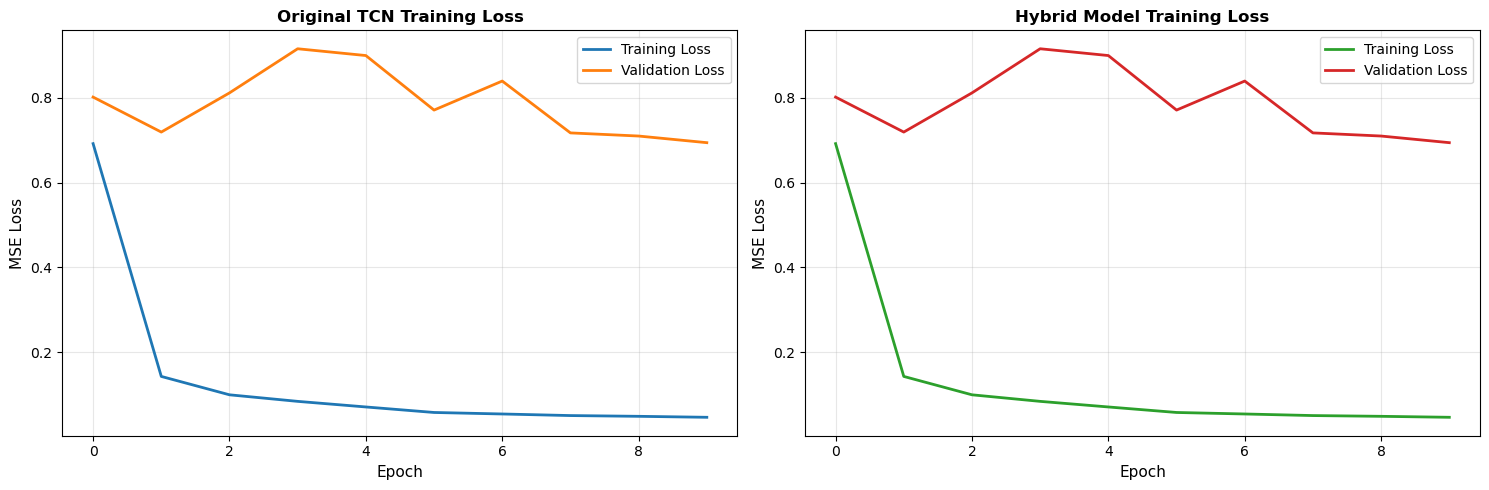

In [ ]:
import matplotlib.pyplot as plt

# Training Loss Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original TCN Training Loss
axes[0].plot(history_hybrid.history['loss'], label='Training Loss', linewidth=2, color='#1f77b4')
if 'val_loss' in history_hybrid.history:
    axes[0].plot(history_hybrid.history['val_loss'], label='Validation Loss', linewidth=2, color='#ff7f0e')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('MSE Loss', fontsize=11)
axes[0].set_title('Original TCN Training Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Hybrid Model Training Loss
axes[1].plot(history_hybrid.history['loss'], label='Training Loss', linewidth=2, color='#2ca02c')
if 'val_loss' in history_hybrid.history:
    axes[1].plot(history_hybrid.history['val_loss'], label='Validation Loss', linewidth=2, color='#d62728')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MSE Loss', fontsize=11)
axes[1].set_title('Hybrid Model Training Loss', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

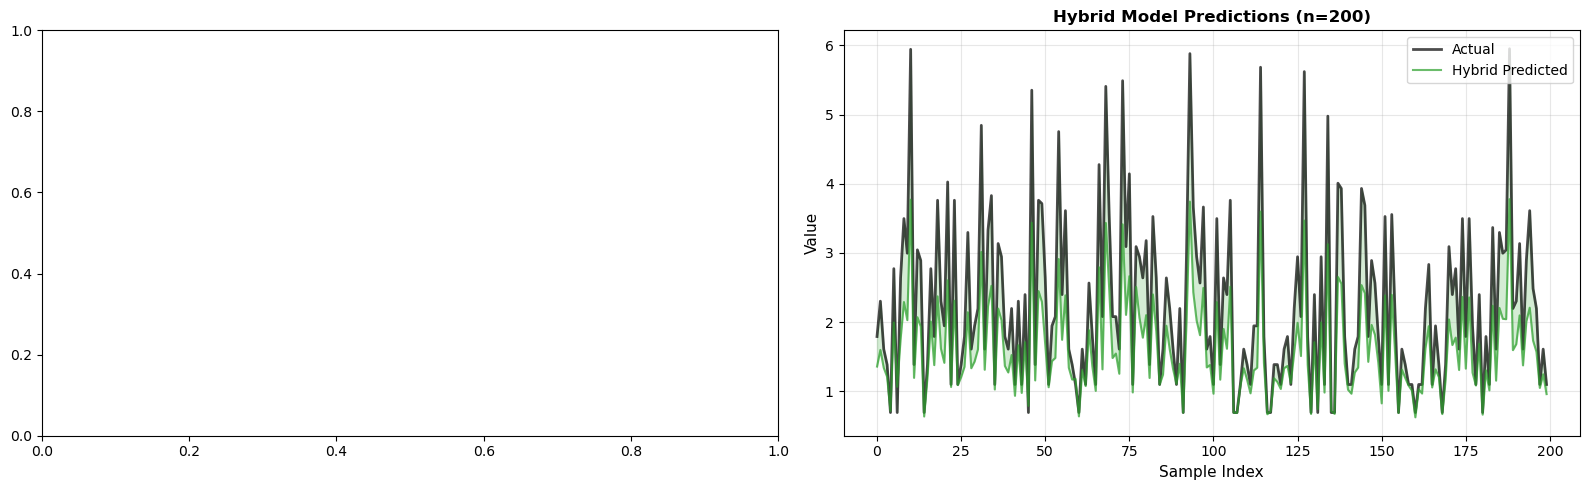

In [ ]:
# Predictions Visualization: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sample first 200 test predictions for clarity
sample_size = min(200, len(y_test_hybrid))
sample_indices = np.random.choice(len(y_test_hybrid), sample_size, replace=False)
sample_indices = np.sort(sample_indices)

# Hybrid Model Predictions
preds_hybrid_sample = preds_hybrid[sample_indices]
y_hybrid_sample = y_test_hybrid[sample_indices]

axes[1].plot(y_hybrid_sample, label='Actual', linewidth=2, alpha=0.7, color='#000000')
axes[1].plot(preds_hybrid_sample, label='Hybrid Predicted', linewidth=1.5, alpha=0.7, color='#2ca02c')
axes[1].fill_between(range(len(y_hybrid_sample)), y_hybrid_sample, preds_hybrid_sample, alpha=0.2, color='#2ca02c')
axes[1].set_xlabel('Sample Index', fontsize=11)
axes[1].set_ylabel('Value', fontsize=11)
axes[1].set_title(f'Hybrid Model Predictions (n={sample_size})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Baseline
baseline_preds = preds_hybrid

baseline_r2 = r2_score(
    y_test,
    baseline_preds
)

print("Baseline R²:", baseline_r2)

# Feature Importance
from sklearn.metrics import r2_score

feature_importance = {}

X_test_copy = X_test.copy()

for feature_idx, feature_name in enumerate(feature_cols):

    X_permuted = X_test_copy.copy()

    # Shuffle feature across samples
    shuffled = np.random.permutation(
        X_permuted[:, :, feature_idx]
    )

    X_permuted[:, :, feature_idx] = shuffled

    perm_preds = model.predict(
        X_permuted,
        verbose=0
    ).flatten()

    perm_r2 = r2_score(
        y_test,
        perm_preds
    )

    importance = baseline_r2 - perm_r2

    feature_importance[feature_name] = importance

importance_df = (
    pd.DataFrame(
        feature_importance.items(),
        columns=["Feature", "Importance"]
    )
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(importance_df)


Baseline R²: 0.5909977555274963
                Feature  Importance
10                lag_1    3.635643
12                lag_3    3.192175
4              week_sin    2.967893
9                income    2.919218
5              week_cos    2.910611
3                  year    2.841632
2          infection_id    2.821076
0              state_id    2.758310
1             county_id    2.743654
8   population_estimate    2.727540
7             longitude    2.653664
6              latitude    2.610689
13                lag_4    2.595646
11                lag_2    2.544542


In [ ]:
# Getting latitude and longitude importance values
lat_imp = importance_df.loc[
    importance_df["Feature"] == "latitude",
    "Importance"
].values[0]

lon_imp = importance_df.loc[
    importance_df["Feature"] == "longitude",
    "Importance"
].values[0]

# Removing original latitude and longitude rows
importance_df = importance_df[
    ~importance_df["Feature"].isin(["latitude", "longitude"])
].copy()

# Adding Location feature
location_row = pd.DataFrame({
    "Feature": ["Location"],
    "Importance": [lat_imp + lon_imp]
})

importance_df = pd.concat(
    [importance_df, location_row],
    ignore_index=True
)

# Sorting again
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print(importance_df)

                Feature  Importance
0              Location    5.264353
1                 lag_1    3.635643
2                 lag_3    3.192175
3              week_sin    2.967893
4                income    2.919218
5              week_cos    2.910611
6                  year    2.841632
7          infection_id    2.821076
8              state_id    2.758310
9             county_id    2.743654
10  population_estimate    2.727540
11                lag_4    2.595646
12                lag_2    2.544542


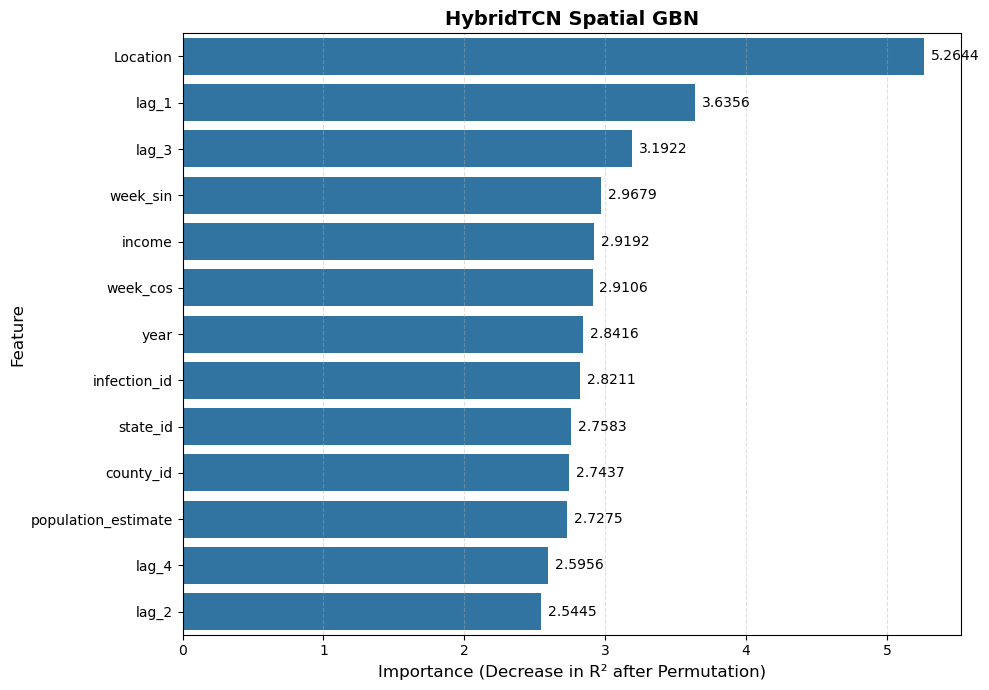

In [ ]:
# Feature Importance Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sort for horizontal plotting
plot_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=plot_df,
    x="Importance",
    y="Feature"
    # palette="viridis"
)

# Add data labels
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.4f}",
        (width, p.get_y() + p.get_height()/2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10
    )

plt.xlabel(
    "Importance (Decrease in R² after Permutation)",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.title(
    "HybridTCN Spatial GBN",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()